## Fitting classifiers

In [26]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import pickle
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
original_df = pd.read_csv('df_transformed.csv')
df = original_df.copy()
df

,valence,popularity,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop
0,0.082296,0.522709,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,False,10,1,3,False,False,True,False
1,1.066102,0.882222,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.100010,-0.467142,False,3,0,4,False,True,False,False
2,1.486579,0.583396,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,False,2,0,4,False,False,False,True
3,0.770855,-1.669934,-0.915276,0.947310,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.079250,-0.727684,False,9,1,4,True,False,False,False
4,-0.098867,0.482969,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.246500,False,4,0,4,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955,1.631696,0.206734,-0.466385,1.080773,0.755239,0.743705,0.931787,0.293986,-0.010363,0.964309,0.322401,False,9,1,4,False,False,False,True
1956,-0.285306,0.616959,-0.378727,-0.436257,0.180213,0.109505,-0.055218,-0.308438,169.740478,-0.244643,-0.086848,False,0,1,4,False,False,False,True
1957,0.209793,-1.669934,-0.844195,0.114556,-0.868563,-0.569369,0.386737,0.075402,-0.010363,-0.109269,0.635944,False,0,1,4,True,False,False,False
1958,1.058974,0.678733,-0.325245,0.131517,-1.850542,1.023206,-0.508212,6.537799,-0.010363,0.781730,-0.751428,False,7,0,4,False,False,False,False


In [4]:
# New target variable
median_popularity = df["popularity"].median()
df['popularity_binary'] = df["popularity"].apply(lambda x: 0 if x <= median_popularity else 1)

In [5]:
# Drop popularity
df = df.drop(columns=["popularity"])
df

,valence,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop,popularity_binary
0,0.082296,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,False,10,1,3,False,False,True,False,0
1,1.066102,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.100010,-0.467142,False,3,0,4,False,True,False,False,1
2,1.486579,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,False,2,0,4,False,False,False,True,1
3,0.770855,-0.915276,0.947310,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.079250,-0.727684,False,9,1,4,True,False,False,False,0
4,-0.098867,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.246500,False,4,0,4,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955,1.631696,-0.466385,1.080773,0.755239,0.743705,0.931787,0.293986,-0.010363,0.964309,0.322401,False,9,1,4,False,False,False,True,0
1956,-0.285306,-0.378727,-0.436257,0.180213,0.109505,-0.055218,-0.308438,169.740478,-0.244643,-0.086848,False,0,1,4,False,False,False,True,1
1957,0.209793,-0.844195,0.114556,-0.868563,-0.569369,0.386737,0.075402,-0.010363,-0.109269,0.635944,False,0,1,4,True,False,False,False,0
1958,1.058974,-0.325245,0.131517,-1.850542,1.023206,-0.508212,6.537799,-0.010363,0.781730,-0.751428,False,7,0,4,False,False,False,False,1


In [16]:
# Let us perform the preprosessing that is not yet done in preprocessing
map_cat = {False: 0, True: 1}
df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']] = df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']].replace(map_cat)
df
# TODO
# Time signaure and key scaling.

C:\Users\pette\AppData\Local\Temp\ipykernel_30704\1796595391.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']] = df[['explicit','track_genre_indie-pop','track_genre_pop','track_genre_r-n-b','track_genre_synth-pop']].replace(map_cat)


,valence,acousticness,loudness,duration_ms,danceability,energy,speechiness,instrumentalness,liveness,tempo,explicit,key,mode,time_signature,track_genre_indie-pop,track_genre_pop,track_genre_r-n-b,track_genre_synth-pop,popularity_binary
0,0.082296,0.448524,0.953983,-0.125232,-0.201751,-0.343045,-0.418492,-0.010363,0.249932,0.528641,0,10,1,3,0,0,1,0,0
1,1.066102,-0.659722,0.650076,-0.038716,0.651736,-0.114681,0.138373,0.025675,0.100010,-0.467142,0,3,0,4,0,1,0,0,1
2,1.486579,0.003012,-0.589184,0.708688,0.758137,-0.118417,-0.331233,0.006187,1.429284,-0.012694,0,2,0,4,0,0,0,1,1
3,0.770855,-0.915276,0.947310,-0.317469,-0.342557,0.642412,2.783162,-0.010363,1.079250,-0.727684,0,9,1,4,1,0,0,0,0
4,-0.098867,-0.039238,0.068956,0.964428,0.304195,0.247682,-0.075669,0.013611,-0.595249,0.246500,0,4,0,4,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1955,1.631696,-0.466385,1.080773,0.755239,0.743705,0.931787,0.293986,-0.010363,0.964309,0.322401,0,9,1,4,0,0,0,1,0
1956,-0.285306,-0.378727,-0.436257,0.180213,0.109505,-0.055218,-0.308438,169.740478,-0.244643,-0.086848,0,0,1,4,0,0,0,1,1
1957,0.209793,-0.844195,0.114556,-0.868563,-0.569369,0.386737,0.075402,-0.010363,-0.109269,0.635944,0,0,1,4,1,0,0,0,0
1958,1.058974,-0.325245,0.131517,-1.850542,1.023206,-0.508212,6.537799,-0.010363,0.781730,-0.751428,0,7,0,4,0,0,0,0,1


In [17]:
# Divide to training and testing
y = df["popularity_binary"]
X = df.drop(columns=["popularity_binary"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [18]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [21]:
# Parameter grid
param_grid = {
    'C': [0.1],
    'gamma': [1],
    'kernel': ['linear']
}

# Note that hyperparameters of the preprocessing transformers can also be included
# in the parameter grid. For simplicity, we do not tune them here.

svm_search = GridSearchCV(
    svm.SVC(probability=True),
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
svm_search.fit(X_train, y_train) 

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_

Best CV F1 = 0.655
Best parameters:  {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}


In [22]:
# Parameter grid
param_grid = {
    'n_estimators': [10, 20, 30],
    'max_depth': [2, 4, 6, 8, 10]
}

r_forest_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
r_forest_search.fit(X_train, y_train) 

print(f"Best CV F1 = {r_forest_search.best_score_:.3f}")
print("Best parameters: ", r_forest_search.best_params_)

# store the best params and best model for later use
r_forest_best_params = r_forest_search.best_params_
r_forest_best_model = r_forest_search.best_estimator_
r_forest_best_cv_f1 = r_forest_search.best_score_

Best CV F1 = 0.710
Best parameters:  {'max_depth': 10, 'n_estimators': 30}


In [27]:
# Parameter grid
param_grid = {
    'var_smoothing': [0.00001, 0.001, 0.1]
}

NB_search = GridSearchCV(
    GaussianNB(),
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
NB_search.fit(X_train, y_train) 

print(f"Best CV F1 = {NB_search.best_score_:.3f}")
print("Best parameters: ", NB_search.best_params_)

# store the best params and best model for later use
NB_best_params = NB_search.best_params_
NB_best_model = NB_search.best_estimator_
NB_best_cv_f1 = NB_search.best_score_

Best CV F1 = 0.580
Best parameters:  {'var_smoothing': 1e-05}


In [28]:
# Compute CV metrics (mean ± std) for the *best* SVM and RF models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": r_forest_best_model,
    "Gaussian Naive Bayes (best by F1)": NB_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")




SVM (best by F1)
  F1-score : mean=0.655, std=0.024
  Precision: mean=0.578, std=0.028
  Recall   : mean=0.757, std=0.037
  ROC_AUC  : mean=0.644, std=0.039
  AP       : mean=0.620, std=0.048

Random Forest (best by F1)
  F1-score : mean=0.690, std=0.050
  Precision: mean=0.687, std=0.052
  Recall   : mean=0.693, std=0.053
  ROC_AUC  : mean=0.761, std=0.046
  AP       : mean=0.737, std=0.053

Gaussian Naive Bayes (best by F1)
  F1-score : mean=0.580, std=0.060
  Precision: mean=0.602, std=0.042
  Recall   : mean=0.563, std=0.080
  ROC_AUC  : mean=0.642, std=0.040
  AP       : mean=0.618, std=0.056


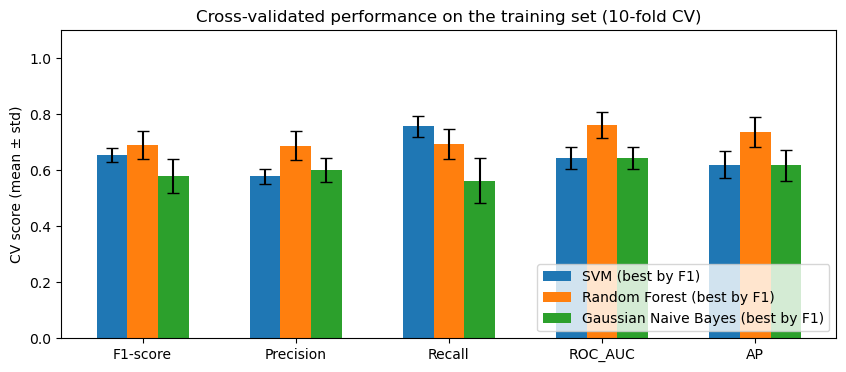

In [32]:
# Plot mean ± std for each metric
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x , means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x + width, means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()
